In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Helper Functions

In [20]:
def plot_heat_map(df):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
    plt.title("Covariance Heatmap")
    plt.tight_layout()
    plt.show()

In [21]:
def plot_vif_bar(vif_df):
    plt.figure(figsize=(10, 6))
    sns.barplot(x="VIF", y="Feature", data=vif_df, palette="coolwarm")
    plt.title("Variance Inflation Factor (VIF) per Feature")
    plt.xlabel("VIF Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [22]:
def plot_mi(df):
    X = df.drop(columns=['reading_time'])  # all features
    y = df['reading_time']
    
    # Compute mutual information
    mi_scores = mutual_info_regression(X, y, discrete_features='auto')
    
    # Put results in a DataFrame
    mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
    mi_df.sort_values(by='MI Score', ascending=False, inplace=True)
    
    # Plot as a heatmap (bar-like)
    plt.figure(figsize=(10, 6))
    sns.heatmap(mi_df.set_index('Feature').T, cmap="YlGnBu", annot=True, cbar=True)
    plt.title("Mutual Information with Reading Time")
    plt.show()

In [23]:
df = pd.read_csv('../data/data_with_polysemy.csv')
df = df.rename(columns={
    "DATA_FILE": "subject_id",
    "IA_DWELL_TIME": "reading_time",
    "V.Mean.Sum": "valence",
    "A.Mean.Sum": "arousal",
    "D.Mean.Sum": "dominance"
})
df = df[['reading_time', 'FREQ_WEB', 'WORD_LEN', 'SURP_GPT2', 'valence', 'arousal', 'dominance', 'orth_size', 'polysemy_count', 'answered_correctly']]
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# all data analysis 

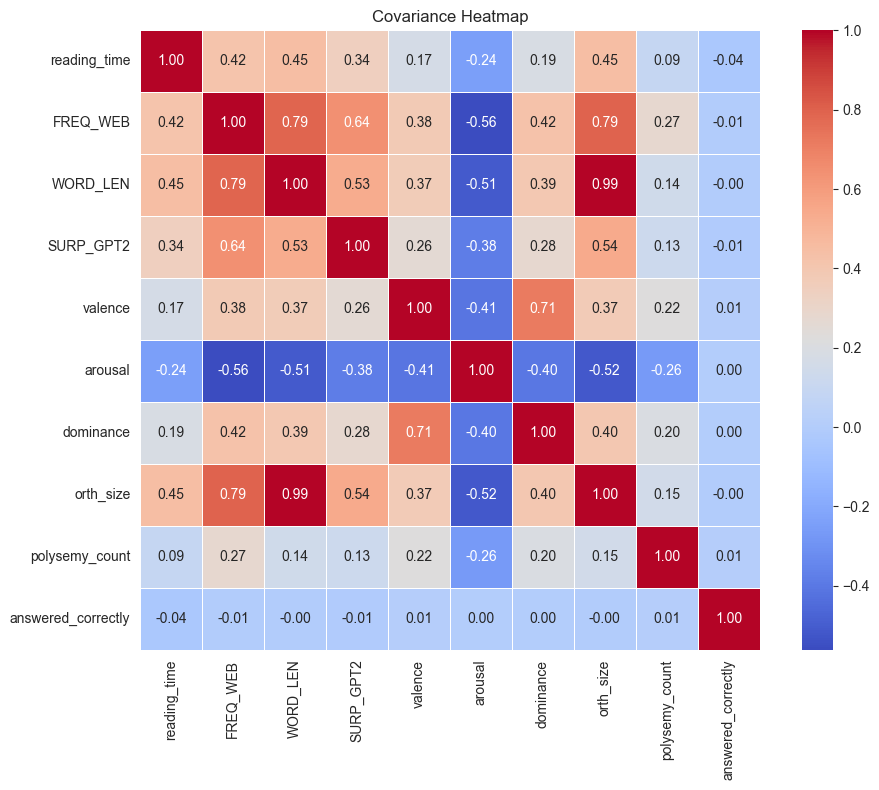

In [24]:
cor_matrix = df.corr(method='spearman')
plot_heat_map(cor_matrix)

C:\Users\User\AppData\Local\Temp\ipykernel_24156\3630391762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_df, palette="coolwarm")


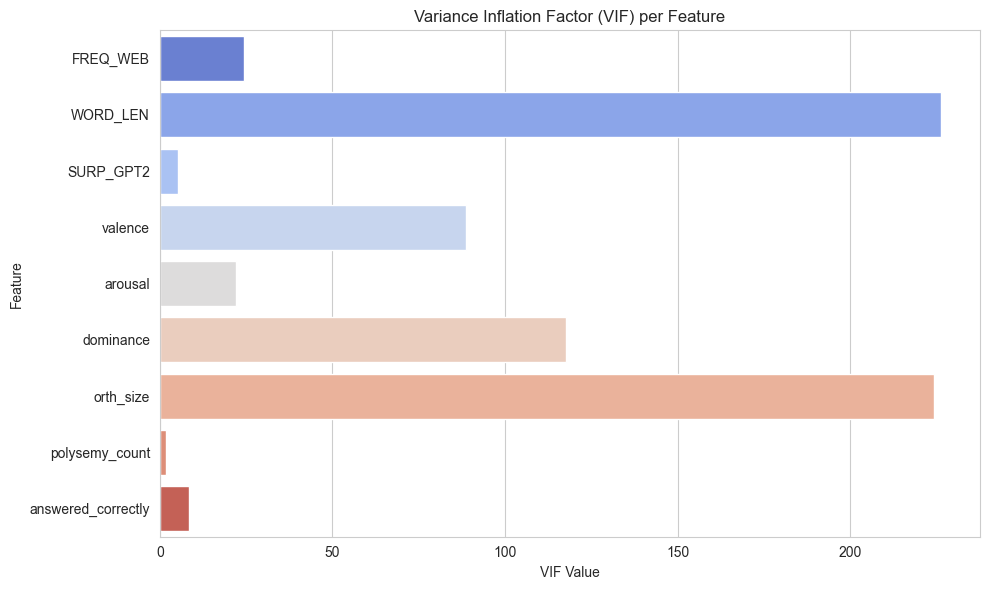

In [25]:
data = df.drop(columns=['reading_time'])
X = data.dropna().values
vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'Feature': data.columns, 'VIF': vif})
plot_vif_bar(vif_df)


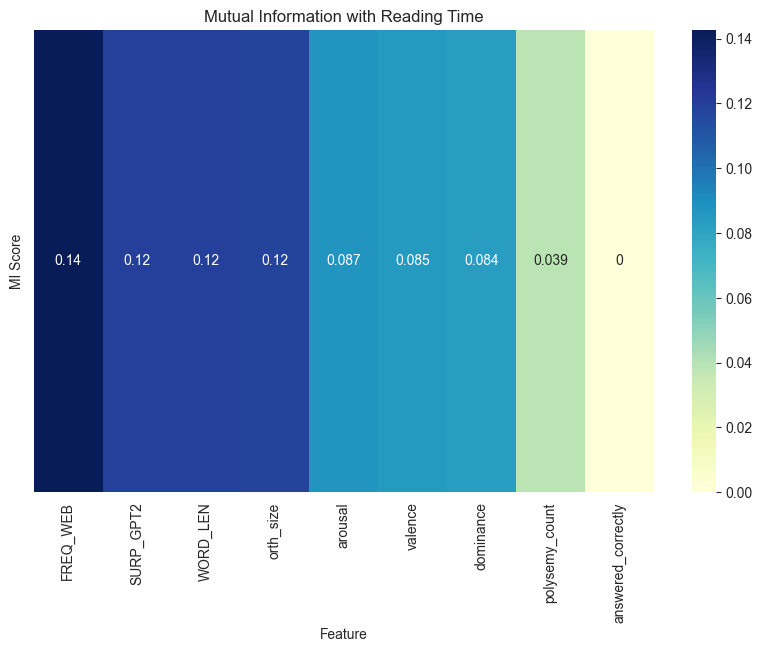

In [26]:

plot_mi(df)


# L1 data

In [30]:
df = pd.read_csv('../data/data_with_polysemy.csv')
df = df.rename(columns={
    "DATA_FILE": "subject_id",
    "IA_DWELL_TIME": "reading_time",
    "V.Mean.Sum": "valence",
    "A.Mean.Sum": "arousal",
    "D.Mean.Sum": "dominance"
})
df = df[['reading_time', 'FREQ_WEB', 'WORD_LEN', 'SURP_GPT2', 'valence', 'arousal', 'dominance', 'orth_size', 'polysemy_count', 'answered_correctly', 'Native English']]
df = df.replace([np.inf, -np.inf], np.nan).dropna()
l1_df = df[df['Native English'] == 1].drop("Native English", axis=1)
l2_df = df[df['Native English'] == 0].drop("Native English", axis=1)


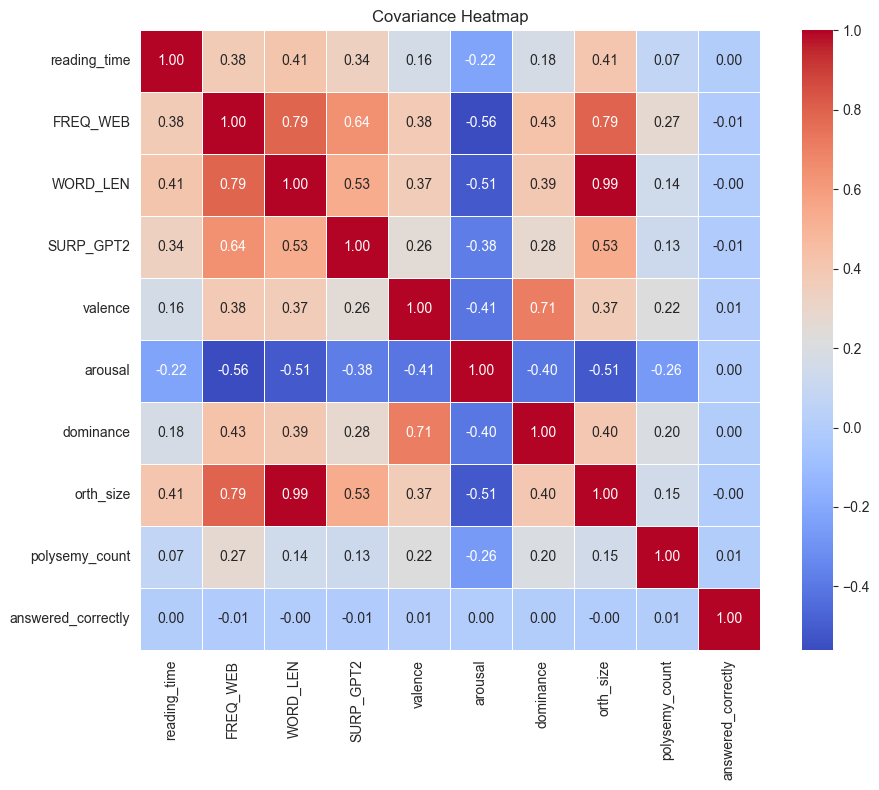

In [31]:
cor_matrix = l1_df.corr(method='spearman')
plot_heat_map(cor_matrix)

C:\Users\User\AppData\Local\Temp\ipykernel_24156\3630391762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_df, palette="coolwarm")


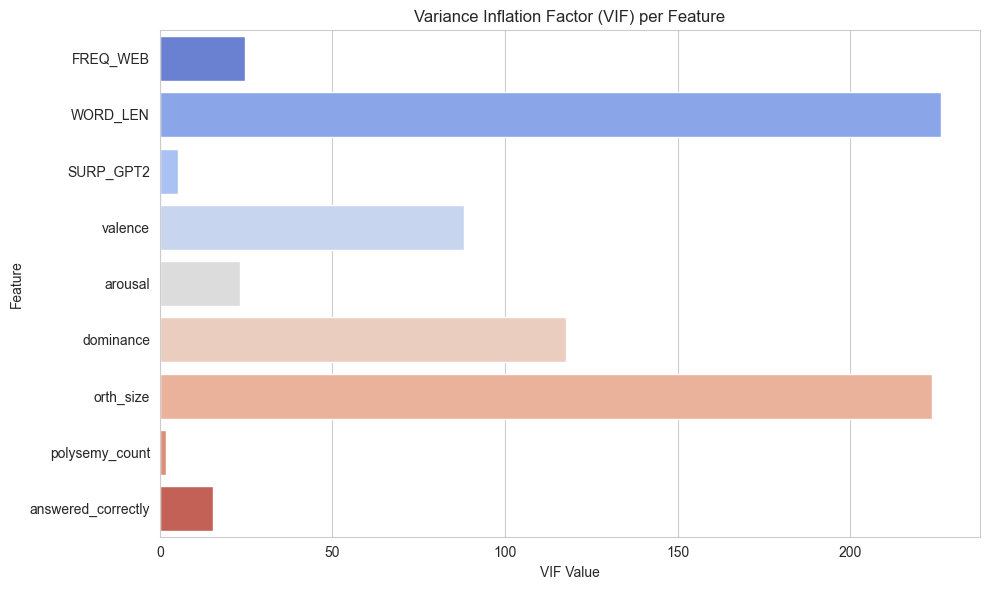

In [33]:
data = l1_df.drop(columns=['reading_time'])
X = data.dropna().values
vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'Feature': data.columns, 'VIF': vif})
plot_vif_bar(vif_df)

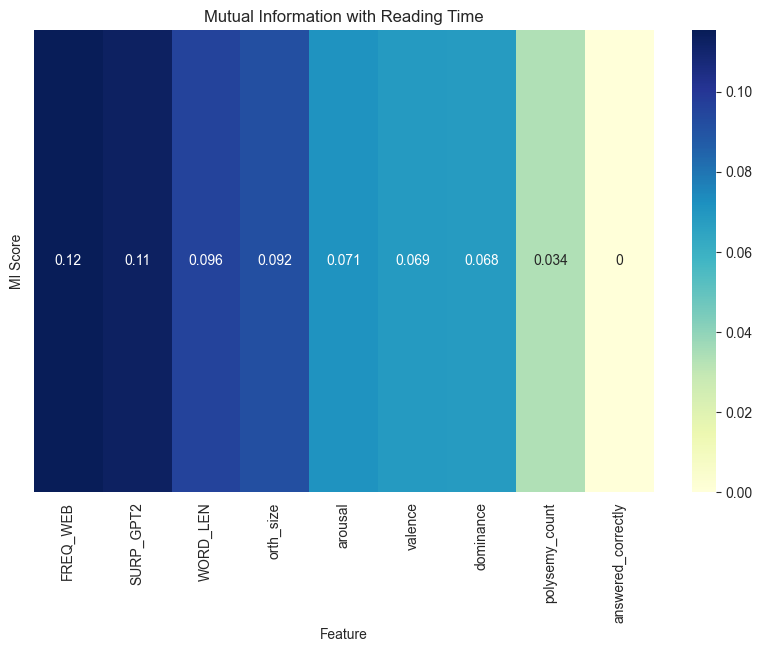

In [34]:
plot_mi(l1_df)

# L2 analysis 

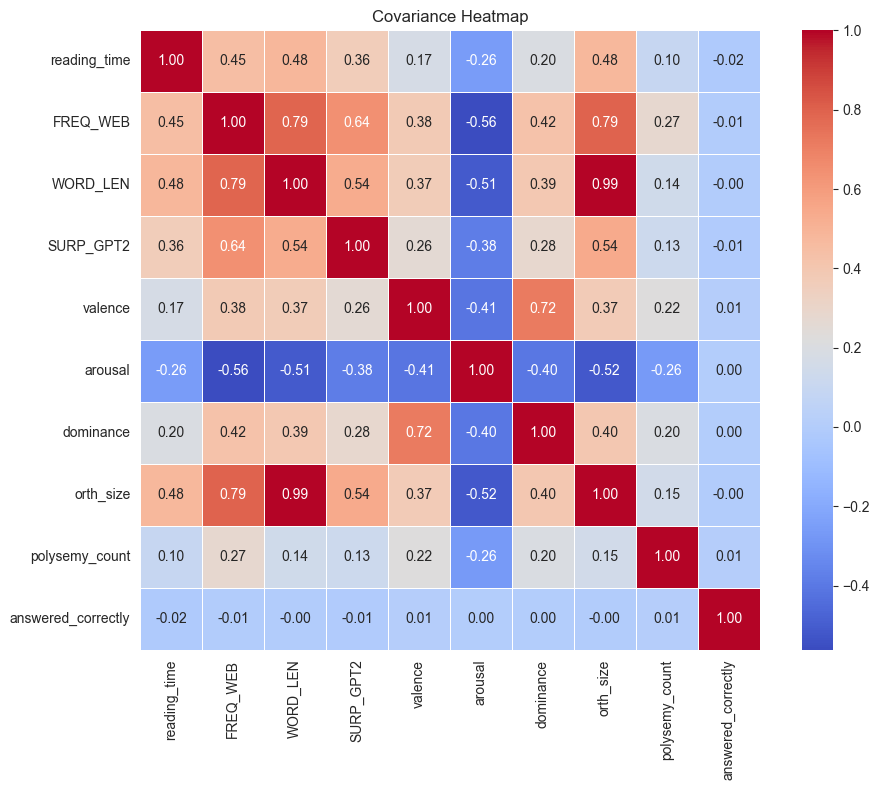

In [35]:
cor_matrix = l2_df.corr(method='spearman')
plot_heat_map(cor_matrix)

C:\Users\User\AppData\Local\Temp\ipykernel_24156\3630391762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="Feature", data=vif_df, palette="coolwarm")


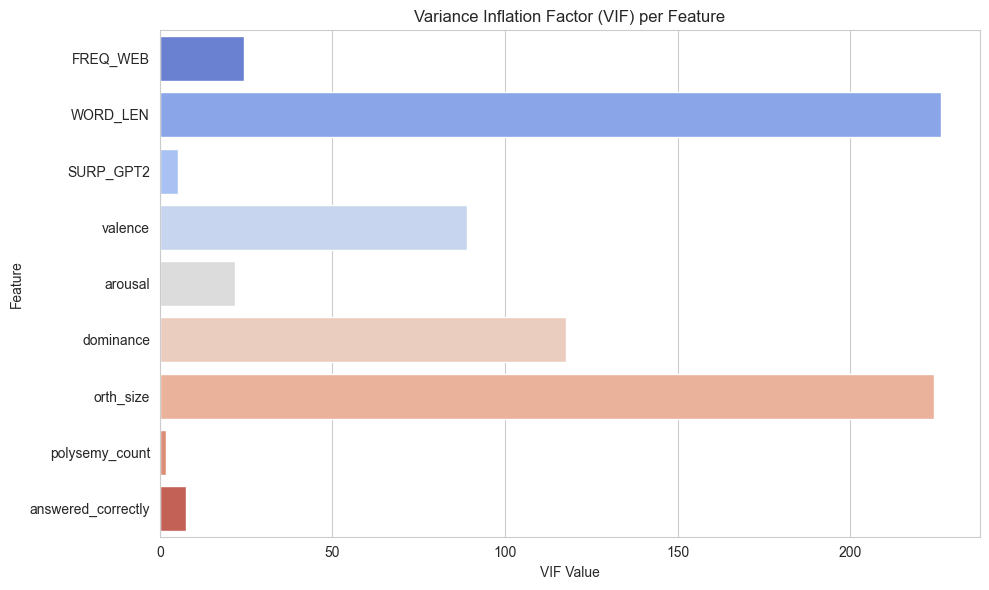

In [36]:
data = l2_df.drop(columns=['reading_time'])
X = data.dropna().values
vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'Feature': data.columns, 'VIF': vif})
plot_vif_bar(vif_df)

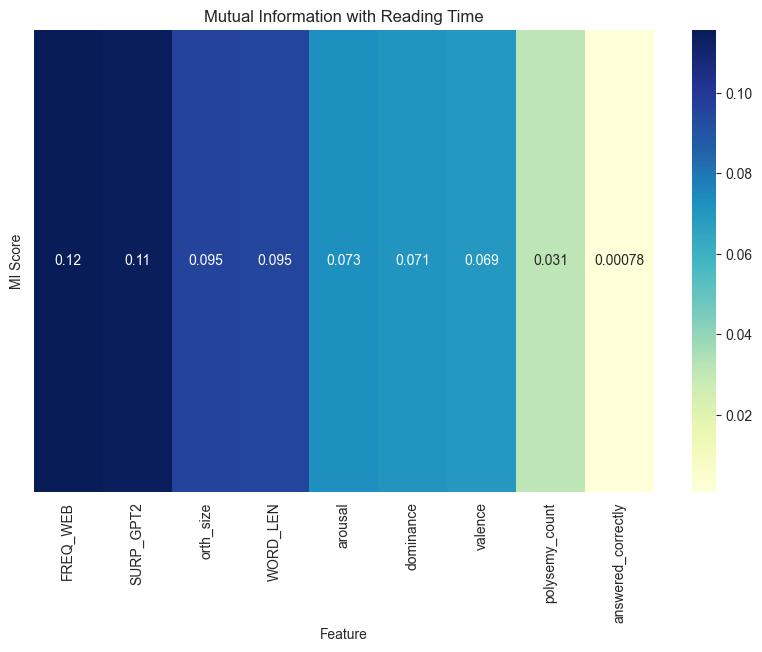

In [37]:
plot_mi(l1_df)